In [1]:
from ase.build import fcc111, fcc100
from ase.calculators.espresso import Espresso, EspressoProfile
import numpy as np
import os; 
from ase.visualize import view
from ase.build import bulk


from ase.io.trajectory import Trajectory
from ase.eos import EquationOfState
from ase.io import read
from ase.units import kJ

In [2]:
# Define pseudopotentials and input data for Quantum ESPRESSO
profile = EspressoProfile(
    command='mpirun -np 4 /usr/bin/pw.x', pseudo_dir='./pseudos')
pseudopotentials = {'Cu': 'Cu.pbe-dn-kjpaw_psl.1.0.0.UPF'} # a dict!

input_data = {
    'control': {
        'calculation': 'scf',
        'verbosity': 'high',
    },
    'system': {
        'ecutwfc': 50,    # Plane-wave cutoff energy in Ry
        'ecutrho': 400,   # Charge density cutoff in Ry
        'occupations': 'smearing',
        'smearing': 'mp',
        'degauss': 0.02,  # Width of smearing in Ry
    },
    'electrons': {
        'conv_thr': 1e-6,  # Convergence threshold
    },
}
kpts = (2, 2, 2)  # k-point grid for the slab

In [3]:
calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=True, tprnfor=True, kpts=kpts, input_data=input_data)

In [4]:
#lat = bulk('Cu', 'fcc', a=3.62)
#from ase.io import read, write
#write('latt.cif', lat)


lat=read('fcc_111_112_011.cif')
for a in lat.get_positions():
    print(a)
    

[0. 0. 0.]
[0.         1.48193985 2.09577924]
[0.         2.96388415 4.19156476]
[1.283399   3.70485185 2.09577924]
[1.283399 2.222912 0.      ]
[1.283399   0.74097215 4.19156476]


In [5]:
from ase.visualize import view 
view(lat, viewer="ngl")

In [6]:
lat.calc = calc 
e=lat.get_potential_energy()

print(f"total energy is: {e}")

total energy is: -17393.43824706391


In [7]:
import re
import matplotlib.pyplot as plt

scf_energies = []
with open("espresso.pwo", "r") as file:
    for line in file:
        if "total energy" in line:
            try:
                # Extract the 4th element and convert to float
                energy = float(line.split()[3])
                scf_energies.append(energy)
                print(energy)
            except (IndexError, ValueError):
                # Handle lines that do not match the expected format
                pass
                #print(f"Skipping line due to format issue: {line}")

-1278.21600523
-1278.23553701
-1278.39267723
-1278.39287773
-1278.39428259
-1278.39418348
-1278.39423952
-1278.39424254


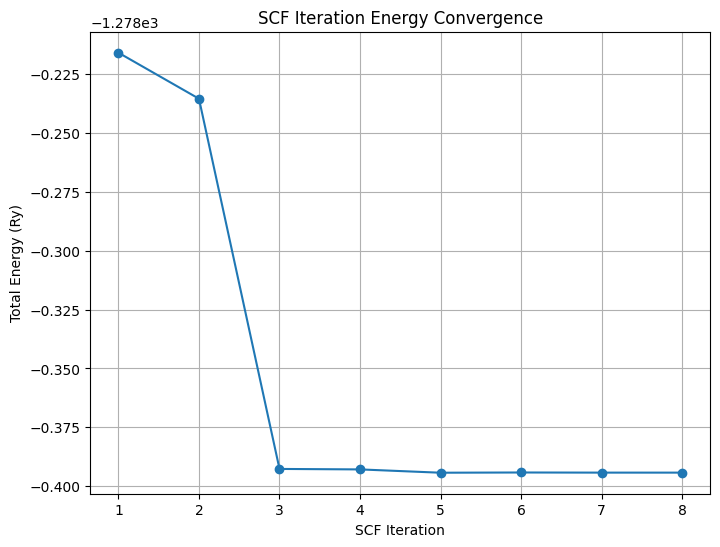

In [8]:
# Plot SCF iteration energies
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(scf_energies) + 1), scf_energies, marker="o", linestyle="-")
plt.title("SCF Iteration Energy Convergence")
plt.xlabel("SCF Iteration")
plt.ylabel("Total Energy (Ry)")
plt.grid(True)
plt.show()

In [9]:
cell = lat.get_cell()

In [10]:
cell

Cell([2.566798, 4.445824, 6.287344])

In [11]:
cell[2,2] = cell[2,2] + 10 

In [12]:
cell

Cell([2.566798, 4.445824, 16.287344])

In [13]:
slab = lat.copy()

In [14]:
slab.set_cell(cell)

In [15]:
view(slab, viewer='ngl')

In [16]:
kpts = (2, 2, 1) 

In [17]:
calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=True, tprnfor=True, kpts=kpts, input_data=input_data)


In [18]:
slab.calc=calc

In [19]:
es=slab.get_potential_energy()

In [20]:
cell = slab.get_cell()
Area = cell[0,0] * cell[1,1]
print(cell[0,:], cell[1,:], cell[2,:], "Area=", Area)


[2.566798 0.       0.      ] [0.       4.445824 0.      ] [ 0.        0.       16.287344] Area= 11.411532151551999


In [21]:
gamma = (es-e)/(2*Area) 

In [22]:
print(f"gamma = {gamma*16.02176565  } $J/m^2$")  # J/m^2 

gamma = 1.6264370096509417 $J/m^2$


In [23]:
alat=3.63

In [24]:
np.sqrt(3)*alat

6.287344431475024

In [25]:
np.sqrt(2)/2*alat

2.5667976157071677

In [26]:
np.sqrt(6)/2 * alat 

4.445823883151467